___

<a href='http://www.pieriandata.com'> <img src='../Pierian_Data_Logo.png' /></a>
___

# Finance Data Project 

In this data project we will focus on exploratory data analysis of stock prices. Keep in mind, this project is just meant to practice your visualization and pandas skills, it is not meant to be a robust financial analysis or be taken as financial advice.
____
** NOTE: This project is extremely challenging because it will introduce a lot of new concepts and have you looking things up on your own (we'll point you in the right direction) to try to solve the tasks issued. Feel free to just go through the solutions lecture notebook and video as a "walkthrough" project if you don't want to have to look things up yourself. You'll still learn a lot that way! **
____
We'll focus on bank stocks and see how they progressed throughout the [financial crisis](https://en.wikipedia.org/wiki/Financial_crisis_of_2007%E2%80%9308) all the way to early 2016.

## Get the Data

In this section we will learn how to use pandas to directly read data from Google finance using pandas!

First we need to start with the proper imports, which we've already laid out for you here.

*Note: [You'll need to install pandas-datareader for this to work!](https://github.com/pydata/pandas-datareader) Pandas datareader allows you to [read stock information directly from the internet](http://pandas.pydata.org/pandas-docs/stable/remote_data.html) Use these links for install guidance (**pip install pandas-datareader**), or just follow along with the video lecture.*

### The Imports

Already filled out for you.

In [1]:
from pandas_datareader import data, wb
import pandas as pd
import numpy as np
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
%matplotlib inline

## Data

We need to get data using pandas datareader. We will get stock information for the following banks:
*  Bank of America
* CitiGroup
* Goldman Sachs
* JPMorgan Chase
* Morgan Stanley
* Wells Fargo

** Figure out how to get the stock data from Jan 1st 2006 to Jan 1st 2016 for each of these banks. Set each bank to be a separate dataframe, with the variable name for that bank being its ticker symbol. This will involve a few steps:**
1. Use datetime to set start and end datetime objects.
2. Figure out the ticker symbol for each bank.
2. Figure out how to use datareader to grab info on the stock.

** Use [this documentation page](https://pandas-datareader.readthedocs.io/en/latest/remote_data.html) for hints and instructions (it should just be a matter of replacing certain values. Use google finance as a source, for example:**
    
    # Bank of America
    BAC = data.DataReader("BAC", 'google', start, end)

### WARNING: MAKE SURE TO CHECK THE LINK ABOVE FOR THE LATEST WORKING API. "google" MAY NOT ALWAYS WORK. 
------------
### We also provide pickle file in the article lecture right before the video lectures.

In [2]:
start = datetime.datetime(2006, 1, 1)
end = datetime.datetime(2016, 1, 1)

In [3]:
tickers = ['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']

In [5]:
bank_stocks = yf.download(tickers, start=start, end=end)
bank_stocks.head()

[*********************100%***********************]  6 of 6 completed


Price           Close                                                          \
Ticker            BAC           C         GS        JPM         MS        WFC   
Date                                                                            
2006-01-03  30.487936  314.316772  93.359016  23.633688  31.182055  18.274660   
2006-01-04  30.164145  308.513824  92.069481  23.497274  31.203445  18.062700   
2006-01-05  30.203005  310.044220  92.033295  23.568443  31.289001  18.042639   
2006-01-06  30.157665  310.044220  93.337280  23.734495  31.321089  18.148632   
2006-01-09  30.177113  308.577576  94.460167  24.120003  31.652637  18.145767   

Price            High                                    ...       Open  \
Ticker            BAC           C         GS        JPM  ...         GS   
Date                                                     ...              
2006-01-03  30.552693  314.890688  93.771954  23.733657  ...  91.786976   
2006-01-04  30.591545  313.105191  93.387973  23.805669  ...  92.257838   
2006-01-05  30.326046  311.064506  92.236138  23.609958  ...  91.279873   
2006-01-06  30.377842  311.829740  93.634305  23.864970  ...  92.214396   
2006-01-09  30.416718  310.809486  94.626786  24.149658  ...  93.090969   

Price                                          Volume                    \
Ticker            JPM         MS        WFC       BAC        C       GS   
Date                                                                      
2006-01-03  23.421992  30.572423  18.102799  16296700  1537600  6188700   
2006-01-04  23.592165  31.390614  18.217375  17757900  1870960  4861600   
2006-01-05  23.491344  31.310392  18.045503  14970700  1143160  3717400   
2006-01-06  23.675187  31.428042  18.091344  12599800  1370210  4319600   
2006-01-09  23.651482  31.353171  18.145767  15619400  1680740  4723500   

Price                                    
Ticker           JPM       MS       WFC  
Date                                     
2006-01-03  12838600  5377000  11016400  
2006-01-04  13491500  7977800  10870000  
2006-01-05   8109400  5778000  10158000  
2006-01-06   7966900  6889800   8403800  
2006-01-09  16575200  4144500   5619600  

[5 rows x 30 columns]

** Create a list of the ticker symbols (as strings) in alphabetical order. Call this list: tickers**

** Use pd.concat to concatenate the bank dataframes together to a single data frame called bank_stocks. Set the keys argument equal to the tickers list. Also pay attention to what axis you concatenate on.**

In [6]:
bank_stocks.columns = bank_stocks.columns.swaplevel(0, 1)
bank_stocks = bank_stocks.sort_index(axis=1)
bank_stocks.columns.names = ['Bank Ticker', 'Stock Info']

bank_stocks.head()

Bank Ticker        BAC                                                      C  \
Stock Info       Close       High        Low       Open    Volume       Close   
Date                                                                            
2006-01-03   30.487936  30.552693  29.885689  30.384321  16296700  314.316772   
2006-01-04   30.164145  30.591545  30.079959  30.436126  17757900  308.513824   
2006-01-05   30.203005  30.326046  29.995780  30.164152  14970700  310.044220   
2006-01-06   30.157665  30.377842  30.015198  30.306608  12599800  310.044220   
2006-01-09   30.177113  30.416718  30.021695  30.254824  15619400  308.577576   

Bank Ticker                                               ...         MS  \
Stock Info         High         Low        Open   Volume  ...      Close   
Date                                                      ...              
2006-01-03   314.890688  306.792053  312.467479  1537600  ...  31.182055   
2006-01-04   313.105191  308.322526  311.574742  1870960  ...  31.203445   
2006-01-05   311.064506  308.641297  308.896369  1143160  ...  31.289001   
2006-01-06   311.829740  307.365920  311.702195  1370210  ...  31.321089   
2006-01-09   310.809486  308.003660  309.916726  1680740  ...  31.652637   

Bank Ticker                                                  WFC             \
Stock Info        High        Low       Open   Volume      Close       High   
Date                                                                          
2006-01-03   31.278312  30.342476  30.572423  5377000  18.274660  18.317626   
2006-01-04   31.700776  31.203445  31.390614  7977800  18.062700  18.228833   
2006-01-05   31.331784  31.026969  31.310392  5778000  18.042639  18.077011   
2006-01-06   31.470822  31.043012  31.428042  6889800  18.148632  18.203055   
2006-01-09   31.706115  31.347823  31.353171  4144500  18.145767  18.231699   

Bank Ticker                                  
Stock Info         Low       Open    Volume  
Date                                         
2006-01-03   17.870784  18.102799  11016400  
2006-01-04   17.968176  18.217375  10870000  
2006-01-05   17.936656  18.045503  10158000  
2006-01-06   17.979634  18.091344   8403800  
2006-01-09   18.077023  18.145767   5619600  

[5 rows x 30 columns]

** Check the head of the bank_stocks dataframe.**

Bank Ticker    BAC                                     C                       \
Stock Info    Open   High    Low  Close    Volume   Open   High    Low  Close   
Date                                                                            
2006-01-03   46.92  47.18  46.15  47.08  16296700  490.0  493.8  481.1  492.9   
2006-01-04   47.00  47.24  46.45  46.58  17757900  488.6  491.0  483.5  483.8   
2006-01-05   46.58  46.83  46.32  46.64  14970900  484.4  487.8  484.0  486.2   
2006-01-06   46.80  46.91  46.35  46.57  12599800  488.8  489.0  482.0  486.2   
2006-01-09   46.72  46.97  46.36  46.60  15620000  486.0  487.4  483.0  483.9   

Bank Ticker             ...        MS                                  WFC  \
Stock Info    Volume    ...      Open   High    Low  Close   Volume   Open   
Date                    ...                                                  
2006-01-03   1537660    ...     57.17  58.49  56.74  58.31  5377000  31.60   
2006-01-04   1871020    ...     58.70  59.28  58.35  58.35  7977800  31.80   
2006-01-05   1143160    ...     58.55  58.59  58.02  58.51  5778000  31.50   
2006-01-06   1370250    ...     58.77  58.85  58.05  58.57  6889800  31.58   
2006-01-09   1680740    ...     58.63  59.29  58.62  59.19  4144500  31.68   

Bank Ticker                                 
Stock Info    High    Low  Close    Volume  
Date                                        
2006-01-03   31.98  31.20  31.90  11016400  
2006-01-04   31.82  31.36  31.53  10871000  
2006-01-05   31.56  31.31  31.50  10158000  
2006-01-06   31.78  31.38  31.68   8403800  
2006-01-09   31.82  31.56  31.68   5619600  

[5 rows x 30 columns]

# EDA

Let's explore the data a bit! Before continuing, I encourage you to check out the documentation on [Multi-Level Indexing](http://pandas.pydata.org/pandas-docs/stable/advanced.html) and [Using .xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html).
Reference the solutions if you can not figure out how to use .xs(), since that will be a major part of this project.

** What is the max Close price for each bank's stock throughout the time period?**

In [7]:
bank_stocks.xs('Close', level=1, axis=1).max()

Bank Ticker
BAC     36.870289
C      374.732605
GS     182.299438
JPM     52.581131
MS      48.881310
WFC     43.081268
dtype: float64

Bank Ticker
BAC     54.90
C      564.10
GS     247.92
JPM     70.08
MS      89.30
WFC     58.52
dtype: float64

** Create a new empty DataFrame called returns. This dataframe will contain the returns for each bank's stock. returns are typically defined by:**

$$r_t = \frac{p_t - p_{t-1}}{p_{t-1}} = \frac{p_t}{p_{t-1}} - 1$$

In [8]:
returns = pd.DataFrame()

** We can use pandas pct_change() method on the Close column to create a column representing this return value. Create a for loop that goes and for each Bank Stock Ticker creates this returns column and set's it as a column in the returns DataFrame.**

In [9]:
bank_stocks.xs('Close', level=1, axis=1)

Bank Ticker,BAC,C,GS,JPM,MS,WFC
Date,,,,,,
2006-01-03,30.487936,314.316772,93.359016,23.633688,31.182055,18.274660
2006-01-04,30.164145,308.513824,92.069481,23.497274,31.203445,18.062700
2006-01-05,30.203005,310.044220,92.033295,23.568443,31.289001,18.042639
2006-01-06,30.157665,310.044220,93.337280,23.734495,31.321089,18.148632
2006-01-09,30.177113,308.577576,94.460167,24.120003,31.652637,18.145767
...,...,...,...,...,...,...
2015-12-24,13.793182,38.984695,147.927887,50.330639,24.204790,40.900055
2015-12-28,13.681364,38.740639,147.238785,50.164375,23.973766,40.795612
2015-12-29,13.801168,39.184402,148.787247,50.685825,24.256952,41.250717


In [10]:
r = bank_stocks.xs('Close', level=1, axis=1)
r2 = r.apply(lambda x : x.pct_change())
r2 = r2.rename(columns=lambda x: x + ' Return')

r2.head()

Bank Ticker,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013813,-0.005772,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001111
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001026,0.005875
2006-01-09,0.000645,-0.004730,0.012030,0.016243,0.010585,-0.000158


In [11]:
returns = r2
returns.head()

Bank Ticker,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013813,-0.005772,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001111
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001026,0.005875
2006-01-09,0.000645,-0.004730,0.012030,0.016243,0.010585,-0.000158


,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013812,-0.014183,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.000951
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005714
2006-01-09,0.000644,-0.004731,0.012030,0.016242,0.010586,0.000000


** Create a pairplot using seaborn of the returns dataframe. What stock stands out to you? Can you figure out why?**

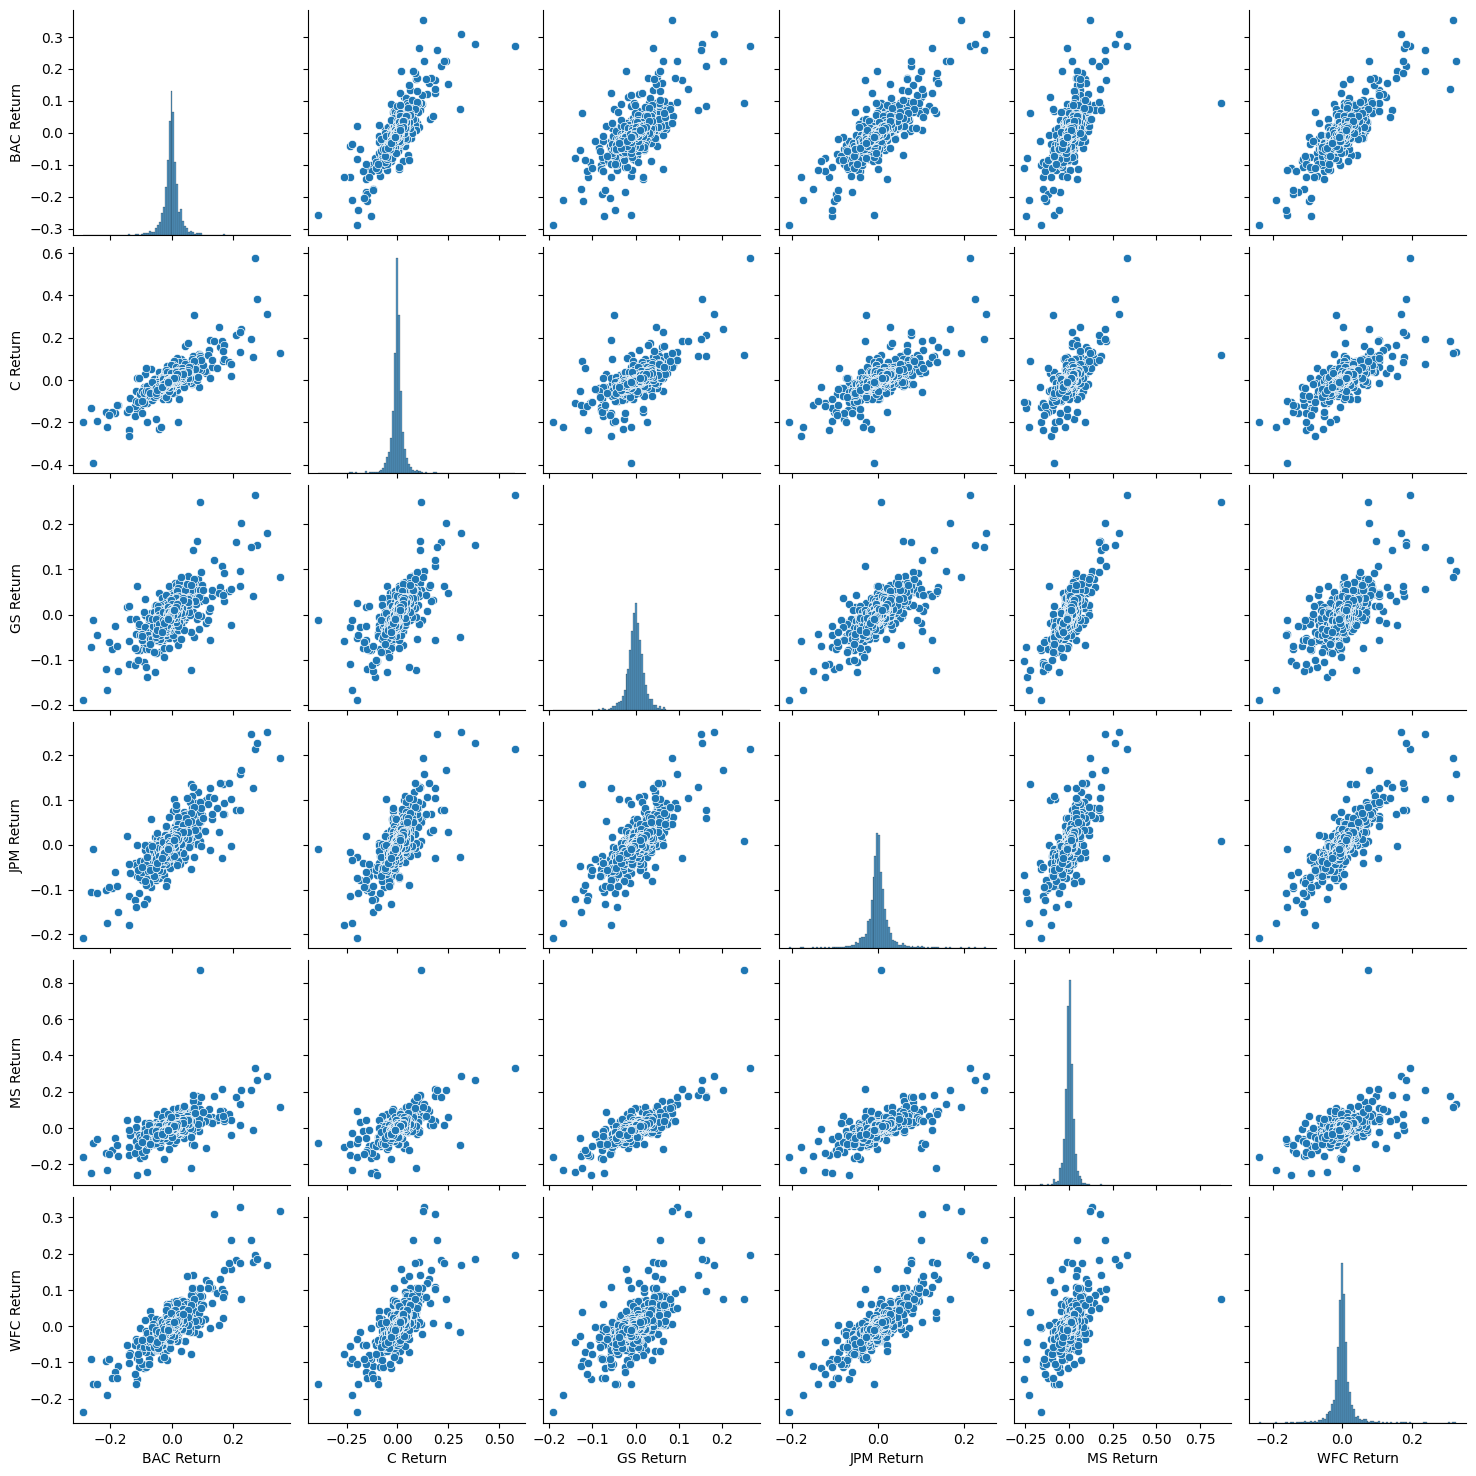

In [12]:
import seaborn as sns
sns.pairplot(data=returns)

plt.show()

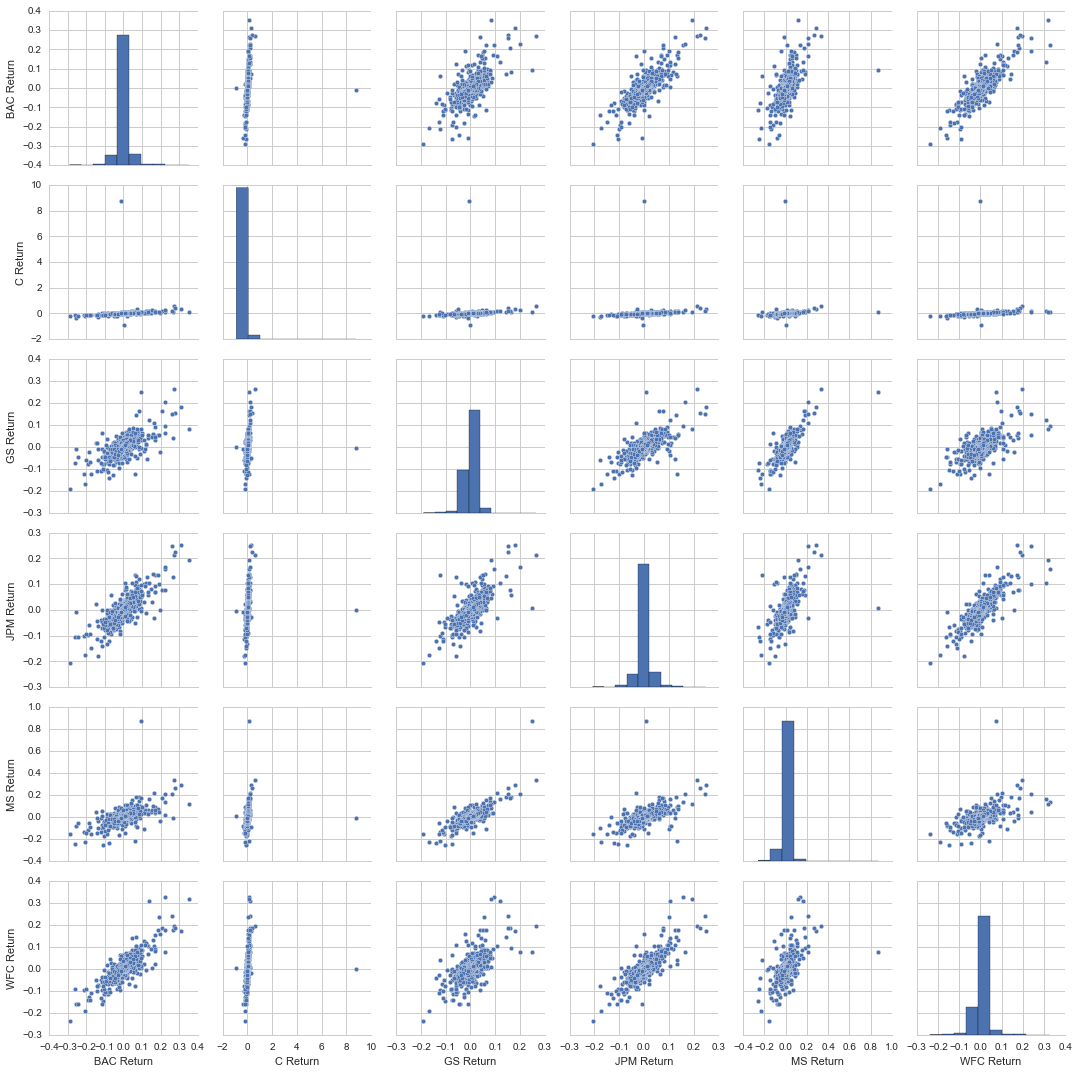

* See solution for details about Citigroup behavior....

** Using this returns DataFrame, figure out on what dates each bank stock had the best and worst single day returns. You should notice that 4 of the banks share the same day for the worst drop, did anything significant happen that day?**

In [13]:
returns.head()

Bank Ticker,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013813,-0.005772,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001111
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001026,0.005875
2006-01-09,0.000645,-0.004730,0.012030,0.016243,0.010585,-0.000158


In [14]:
returns.idxmax()

Bank Ticker
BAC Return   2009-04-09
C Return     2008-11-24
GS Return    2008-11-24
JPM Return   2009-01-21
MS Return    2008-10-13
WFC Return   2008-07-16
dtype: datetime64[ns]

In [15]:
returns.idxmin()

Bank Ticker
BAC Return   2009-01-20
C Return     2009-02-27
GS Return    2009-01-20
JPM Return   2009-01-20
MS Return    2008-10-09
WFC Return   2009-01-20
dtype: datetime64[ns]

BAC Return   2009-01-20
C Return     2011-05-06
GS Return    2009-01-20
JPM Return   2009-01-20
MS Return    2008-10-09
WFC Return   2009-01-20
dtype: datetime64[ns]

** You should have noticed that Citigroup's largest drop and biggest gain were very close to one another, did anythign significant happen in that time frame? **

* See Solution for details

BAC Return   2009-04-09
C Return     2011-05-09
GS Return    2008-11-24
JPM Return   2009-01-21
MS Return    2008-10-13
WFC Return   2008-07-16
dtype: datetime64[ns]

** Take a look at the standard deviation of the returns, which stock would you classify as the riskiest over the entire time period? Which would you classify as the riskiest for the year 2015?**

In [16]:
returns.std()

Bank Ticker
BAC Return    0.036659
C Return      0.038672
GS Return     0.025386
JPM Return    0.027675
MS Return     0.037717
WFC Return    0.030195
dtype: float64

BAC Return    0.036650
C Return      0.179969
GS Return     0.025346
JPM Return    0.027656
MS Return     0.037820
WFC Return    0.030233
dtype: float64

In [17]:
returns.loc['2015'].std()

Bank Ticker
BAC Return    0.016174
C Return      0.015288
GS Return     0.014043
JPM Return    0.014006
MS Return     0.016287
WFC Return    0.012552
dtype: float64

BAC Return    0.016163
C Return      0.015289
GS Return     0.014046
JPM Return    0.014017
MS Return     0.016249
WFC Return    0.012591
dtype: float64

** Create a distplot using seaborn of the 2015 returns for Morgan Stanley **

In [18]:
ms_returns_2015 = returns['MS Return']['2015']
ms_returns_2015

Date
2015-01-02   -0.002319
2015-01-05   -0.031258
2015-01-06   -0.028800
2015-01-07    0.014278
2015-01-08    0.014889
                ...   
2015-12-24   -0.003681
2015-12-28   -0.009545
2015-12-29    0.011812
2015-12-30   -0.009831
2015-12-31   -0.013032
Name: MS Return, Length: 252, dtype: float64

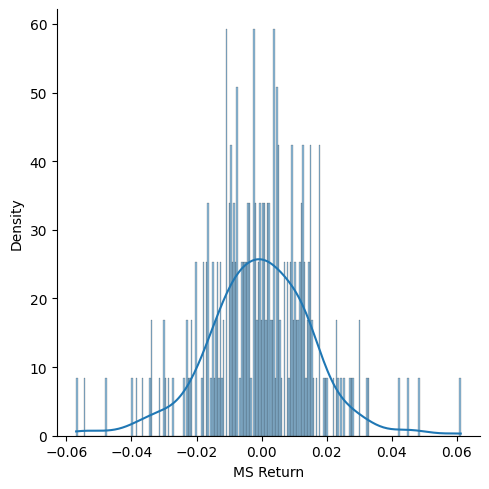

In [19]:
sns.displot(data=ms_returns_2015, kind="hist", kde=True, bins=252, stat='density')
plt.show()

/Users/marci/anaconda/lib/python3.5/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning:

using a non-integer number instead of an integer will result in an error in the future



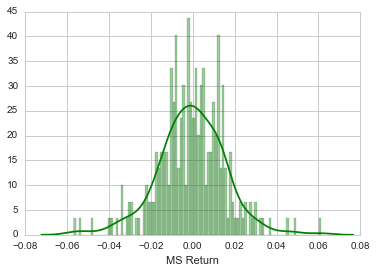

** Create a distplot using seaborn of the 2008 returns for CitiGroup **

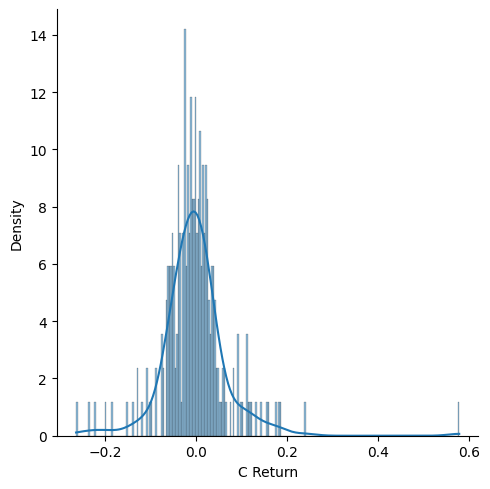

In [20]:
sns.displot(data=returns['C Return']['2008'], kind="hist", kde=True, bins=252, stat='density')
plt.show()

/Users/marci/anaconda/lib/python3.5/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning:

using a non-integer number instead of an integer will result in an error in the future



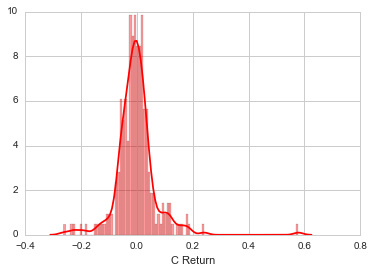

____
# More Visualization

A lot of this project will focus on visualizations. Feel free to use any of your preferred visualization libraries to try to recreate the described plots below, seaborn, matplotlib, plotly and cufflinks, or just pandas.

### Imports

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

# Optional Plotly Method Imports
import plotly
import cufflinks as cf
cf.go_offline()

** Create a line plot showing Close price for each bank for the entire index of time. (Hint: Try using a for loop, or use [.xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html) to get a cross section of the data.)**

In [27]:
close = bank_stocks.xs('Close', level=1, axis=1)

close.columns

Index(['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC'], dtype='object', name='Bank Ticker')

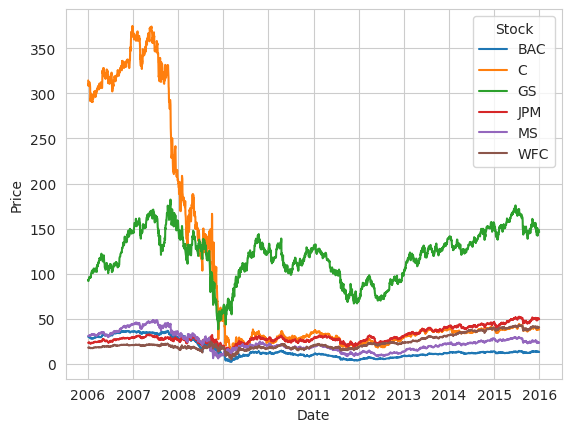

In [37]:
melted = close.reset_index().melt(id_vars='Date', value_vars=['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC'],
                    var_name='Stock', value_name='Price')


sns.lineplot(melted, x='Date', y='Price', hue='Stock')

plt.show()

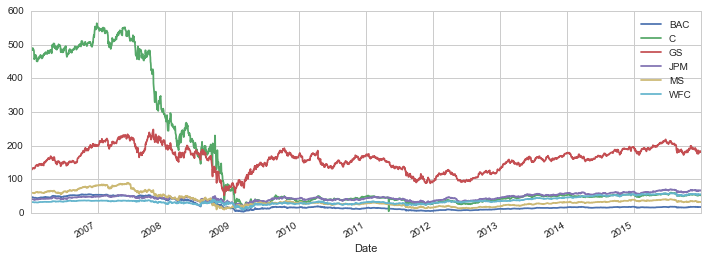

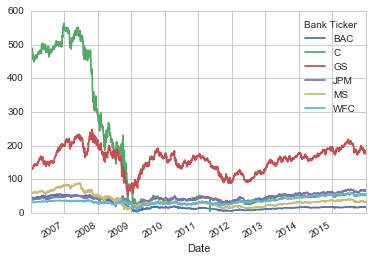

In [38]:
from plotly import __version__
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import download_plotlyjs,init_notebook_mode,plot,iplot
import chart_studio.plotly as py
init_notebook_mode(connected=True)
cf.go_offline()

In [41]:
fig = px.line(close)
fig.show()

## Moving Averages

Let's analyze the moving averages for these stocks in the year 2008. 

** Plot the rolling 30 day average against the Close Price for Bank Of America's stock for the year 2008**

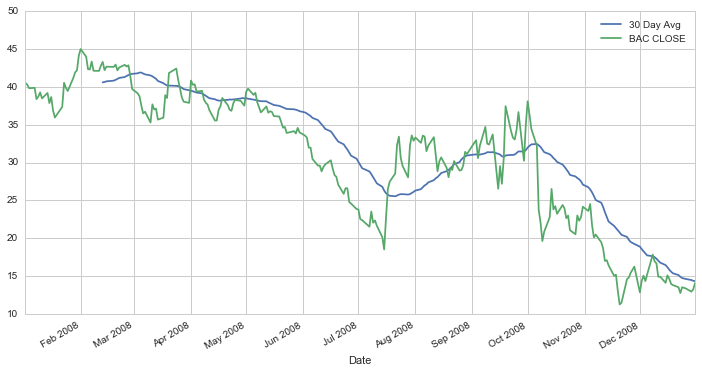

** Create a heatmap of the correlation between the stocks Close Price.**

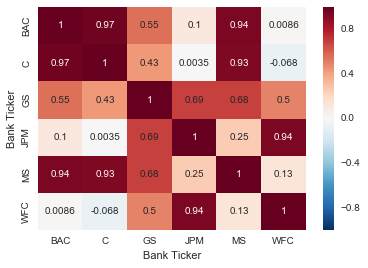

** Optional: Use seaborn's clustermap to cluster the correlations together:**

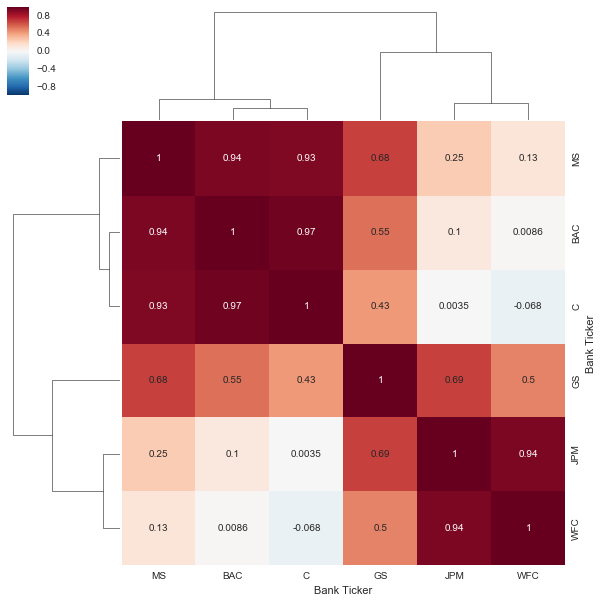

# Part 2 (Optional)

In this second part of the project we will rely on the cufflinks library to create some Technical Analysis plots. This part of the project is experimental due to its heavy reliance on the cuffinks project, so feel free to skip it if any functionality is broken in the future.

** Use .iplot(kind='candle) to create a candle plot of Bank of America's stock from Jan 1st 2015 to Jan 1st 2016.**

** Use .ta_plot(study='sma') to create a Simple Moving Averages plot of Morgan Stanley for the year 2015.**

**Use .ta_plot(study='boll') to create a Bollinger Band Plot for Bank of America for the year 2015.**

# Great Job!

Definitely a lot of more specific finance topics here, so don't worry if you didn't understand them all! The only thing you should be concerned with understanding are the basic pandas and visualization oeprations.